## IMDB Sentiment Analysis using LSTM
### - **By Mahima Bhat**

## 1. Imports

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore")


### 2. Load IMDB Dataset

In [12]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

### 3. Padding

In [13]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

### 4. Build LSTM Model

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. Train Model

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.8054 - loss: 0.4077 - val_accuracy: 0.8600 - val_loss: 0.3357
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9066 - loss: 0.2385 - val_accuracy: 0.8516 - val_loss: 0.3576
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9335 - loss: 0.1777 - val_accuracy: 0.8677 - val_loss: 0.3254
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.9511 - loss: 0.1351 - val_accuracy: 0.8590 - val_loss: 0.4417
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.9590 - loss: 0.1137 - val_accuracy: 0.8594 - val_loss: 0.3994


### 6. Plot Loss & Accuracy

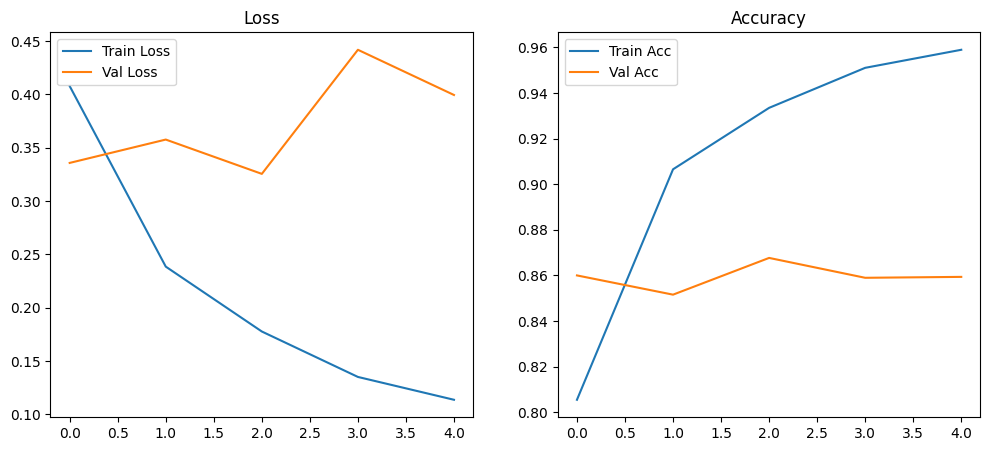

In [16]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.show()

### 7. Evaluate Model

In [17]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8677 - loss: 0.3254
Test Accuracy: 0.867680013179779


### 8. User Input Prediction
Get word index

In [18]:
word_index = tf.keras.datasets.imdb.get_word_index()

Encode user input

In [19]:
def encode_text(text):
    words = text.lower().split()
    encoded = []
    
    for word in words:
        if word in word_index and word_index[word] < 10000:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown word
    
    return pad_sequences([encoded], maxlen=200)

Predict

In [20]:
while True:
    user_input = input("Enter review (or 'exit'): ")
    print("user_input:", user_input)
    
    if user_input.lower() == "exit":
        break
    
    encoded = encode_text(user_input)
    pred = model.predict(encoded)[0][0]
    
    if pred > 0.5:
        print("Positive Review")
    else:
        print("Negative Review")

user_input: this movie is amazing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Positive Review
user_input: this movie is terrible
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Negative Review
user_input: exit
